<a href="https://colab.research.google.com/github/Silva015/tcc-2026/blob/main/Entrada-Saida-ResNet152%2BKAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Ferimentos Balísticos com Transfer Learning e Redes KAN
Este notebook implementa uma abordagem híbrida de Deep Learning para classificar ferimentos de armas de fogo (Entrada vs. Saída).
Utilizamos a arquitetura **ResNet152** pré-treinada para a extração de características espaciais e substituímos o classificador tradicional (MLP) por uma **Kolmogorov-Arnold Network (KAN)** para a tomada de decisão.

## 1. Configuração do Ambiente e Obtenção dos Dados
Instalação das dependências necessárias e clonagem do banco de dados de ferimentos balísticos.

In [1]:
# Instalação da implementação eficiente da rede KAN
!pip install git+https://github.com/Blealtan/efficient-kan -q

# Clonagem dos repositórios contendo os dados e códigos base
!git clone https://gitlab.com/lisa-unb/leguwoi.git -q
!git clone https://github.com/pedrogarciafreitas/FDCPUnBGunshotDB.git -q

import os
from glob import glob
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import torch.nn as nn
import torchvision.models as models
from efficient_kan import KAN
import torch.optim as optim
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def inspecionar_diretorio(caminho_base):
    """Função utilitária para imprimir a estrutura de diretórios ignorando pastas ocultas (.git)"""
    print(f"--- RAIO-X DO DIRETÓRIO: {caminho_base} ---")
    for raiz, diretorios, arquivos in os.walk(caminho_base):
        if '.git' not in raiz:
            print(f"📂 Pasta: {raiz}")
            print(f"   -> Contém {len(arquivos)} arquivos e {len(diretorios)} subpastas.")
            if len(arquivos) > 0:
                print(f"   -> Amostras: {arquivos[:3]}\n")

# Inspecionando a base de dados obtida
inspecionar_diretorio('./FDCPUnBGunshotDB')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
--- RAIO-X DO DIRETÓRIO: ./FDCPUnBGunshotDB ---
📂 Pasta: ./FDCPUnBGunshotDB
   -> Contém 3 arquivos e 3 subpastas.
   -> Amostras: ['README.md', 'CODIGOS.pdf', 'CODES.pdf']

📂 Pasta: ./FDCPUnBGunshotDB/database
   -> Contém 0 arquivos e 2 subpastas.
📂 Pasta: ./FDCPUnBGunshotDB/database/SAIDAS_EQX
   -> Contém 671 arquivos e 0 subpastas.
   -> Amostras: ['2014.0037SH26.38PSTSWATAFALSEXSN04F03_EQX.JPG', '2022.0002SH23.38PCTSWATAFALSEXSN04F02_EQX.JPG', '2019.0065SH24.38PSTSWATAFALSEXSN01F02_EQX.JPG']

📂 Pasta: ./FDCPUnBGunshotDB/database/ENTRADAS_EQX
   -> Contém 0 arquivos e 3 subpastas.
📂 Pasta: ./FDCPUnBGunshotDB/database/ENTRADAS_EQX/ENCOSTADO
   -> Contém 42 arquivos e 0 subpastas.
   -> Amostras: ['2017.0804SH40.38PCTEWSTTYEXSN01F03_EQX.JPG', '2014.0346SH43.38PCTEWSTTYEXNN01F02_EQX.JPG', '2016.0576SH55.40PCTEWSTTYEXSN01F01_EQX.JPG']

📂 Pasta: ./FDCPU

## 2. Ingestão de Dados: Construindo o GunshotDataset (PyTorch)

Esta célula define a "ponte" entre os arquivos de imagem soltos nas pastas do seu Google Drive/Colab e a rede neural. Ela cria uma classe personalizada (`GunshotDataset`) herdando o padrão do PyTorch, que ensina o sistema exatamente como procurar, ler e rotular cada fotografia.

**O que esta célula faz:**

* **Mapeamento Automático (Scraping local):** Utiliza a biblioteca `glob` para vasculhar automaticamente as subpastas em busca de arquivos `.JPG`. Isso evita que você tenha que listar o nome de cada arquivo manualmente.
* **Rotulagem Semântica (Labels):** Associa matematicamente a pasta de origem à classe do ferimento. Imagens vindas da pasta `ENTRADAS_EQX` recebem o rótulo **0**, enquanto as da pasta `SAIDAS_EQX` recebem o rótulo **1**.
* **Carregamento Sob Demanda (Lazy Loading):** Através do método `__getitem__`, as imagens não são todas carregadas na memória RAM de uma só vez (o que travaria o sistema). Em vez disso, o PyTorch abre e converte a imagem para o padrão de cores RGB apenas no exato momento em que ela for necessária para o treinamento.
* **Aplicação de Transformações:** Verifica se algum filtro/transformação (como os definidos para Treino ou Teste) foi passado e aplica essas edições na imagem instantaneamente antes de entregá-la para o modelo.

In [2]:
class GunshotDataset(Dataset):
    """
    Carrega as imagens de ferimentos de arma de fogo e atribui as labels corretas.
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        print("🔄 Mapeando imagens da base de dados...")

        # 1. Mapeamento das imagens de ENTRADA (Label 0)
        caminho_entradas = os.path.join(root_dir, 'database', 'ENTRADAS_EQX', '**', '*.JPG')
        for path in glob(caminho_entradas, recursive=True):
            self.image_paths.append(path)
            self.labels.append(0)

        # 2. Mapeamento das imagens de SAÍDA (Label 1)
        caminho_saidas = os.path.join(root_dir, 'database', 'SAIDAS_EQX', '*.JPG')
        for path in glob(caminho_saidas):
            self.image_paths.append(path)
            self.labels.append(1)

        print(f"✅ Concluído! Total de imagens encontradas: {len(self.image_paths)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

## 3. Preparação de Dados e Separação Semântica Segura (Treino/Teste)

Esta célula é responsável por construir o pipeline de ingestão de dados para o modelo. O foco principal desta etapa é **prevenir o vazamento de dados (data leakage)**. Em vez de realizar um *split* aleatório das imagens (o que poderia colocar imagens diferentes do mesmo caso tanto no treino quanto no teste), a divisão é estritamente baseada no **ID do Caso** (identificado pelos primeiros 9 caracteres do arquivo).

**O que esta célula faz:**

* **Transformações e Data Augmentation:** Cria dois pipelines distintos. O treino recebe transformações agressivas (rotação, espelhamento, jitter de cor) para evitar *overfitting*, enquanto o teste recebe apenas as transformações essenciais (redimensionamento e normalização) para garantir uma métrica de avaliação justa.
* **Reprodutibilidade:** Trava as sementes aleatórias (`seed = 42`) para que a divisão dos dados produza sempre os mesmos resultados em execuções futuras.
* **Separação por Caso (80/20):** Mapeia quais imagens pertencem a qual caso e utiliza o `train_test_split` do *scikit-learn* diretamente na lista de casos únicos, direcionando 80% dos casos para treino e 20% para teste.
* **Criação dos DataLoaders:** Instancia os `DataLoaders` do PyTorch (com tamanho de lote de 32) prontos para iterar durante o loop de treinamento.
* **Sanity Check Automático:** Roda um script de validação de prova real no final da célula que cruza os IDs do treino e do teste. Se a interseção for zero, ele confirma o sucesso; caso contrário, dispara um alerta de vazamento de dados.

In [3]:
import os
import torch
import random
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

# Transformações rigorosas para o TREINO (Prevenção de Overfitting)
transform_treino = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformações puras para o TESTE (Avaliação justa)
transform_teste = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ---------------------------------------------------------
# 1. Configuração de Sementes para Reprodutibilidade
# ---------------------------------------------------------
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# (Presumindo que suas classes GunshotDataset e transformações já estão instanciadas)

# ---------------------------------------------------------
# 2. Instanciação Dupla (Evitando vazamento de transformações)
# ---------------------------------------------------------
dataset_base_treino = GunshotDataset(root_dir='./FDCPUnBGunshotDB', transform=transform_treino)
dataset_base_teste  = GunshotDataset(root_dir='./FDCPUnBGunshotDB', transform=transform_teste)

# ---------------------------------------------------------
# 3. Separação Semântica (Por Caso/Paciente)
# ---------------------------------------------------------
# Dicionário para mapear: '2016.0353' -> [índice_1, índice_2, ...]
case_to_indices = {}

for idx, path in enumerate(dataset_base_treino.image_paths):
    filename = os.path.basename(path)
    # Extrai os 9 primeiros caracteres, ex: '2016.0353'
    case_id = filename[:9]

    if case_id not in case_to_indices:
        case_to_indices[case_id] = []
    case_to_indices[case_id].append(idx)

# Obtém a lista de casos únicos
unique_cases = list(case_to_indices.keys())

# UTILIZANDO O SCIKIT-LEARN: Divisão 80/20 focada nos CASOS
cases_treino, cases_teste = train_test_split(
    unique_cases,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# ---------------------------------------------------------
# 4. Mapeamento de volta para os índices de imagens
# ---------------------------------------------------------
indices_treino = []
for case in cases_treino:
    indices_treino.extend(case_to_indices[case])

indices_teste = []
for case in cases_teste:
    indices_teste.extend(case_to_indices[case])

# ---------------------------------------------------------
# 5. Criação dos Subsets e DataLoaders
# ---------------------------------------------------------
dataset_treino = Subset(dataset_base_treino, indices_treino)
dataset_teste  = Subset(dataset_base_teste, indices_teste)

trainloader = DataLoader(dataset_treino, batch_size=32, shuffle=True)
testloader  = DataLoader(dataset_teste, batch_size=32, shuffle=False)

# ---------------------------------------------------------
# 6. SANITY CHECK PROGRAMÁTICO 🕵️‍♂️
# ---------------------------------------------------------
print("\n" + "="*50)
print("🚀 SANITY CHECK DE VAZAMENTO DE DADOS (CÓDIGO)")
print("="*50)

# Coletando os IDs reais
train_cases_check = set([os.path.basename(dataset_base_treino.image_paths[i])[:9] for i in indices_treino])
test_cases_check  = set([os.path.basename(dataset_base_teste.image_paths[i])[:9] for i in indices_teste])

intersecao = train_cases_check.intersection(test_cases_check)

print(f"📊 Total de Casos Únicos: {len(unique_cases)}")
print(f"   -> Casos no Treino: {len(train_cases_check)} casos ({len(dataset_treino)} imagens)")
print(f"   -> Casos no Teste:  {len(test_cases_check)} casos ({len(dataset_teste)} imagens)")

if len(intersecao) == 0:
    print("\n✅ SUCESSO! Zero interseção semântica identificada pelo código.")
else:
    print(f"\n❌ ALERTA DE VAZAMENTO! {len(intersecao)} casos vazados: {intersecao}")
print("="*50)

🔄 Mapeando imagens da base de dados...
✅ Concluído! Total de imagens encontradas: 2554
🔄 Mapeando imagens da base de dados...
✅ Concluído! Total de imagens encontradas: 2554

🚀 SANITY CHECK DE VAZAMENTO DE DADOS (CÓDIGO)
📊 Total de Casos Únicos: 486
   -> Casos no Treino: 388 casos (2069 imagens)
   -> Casos no Teste:  98 casos (485 imagens)

✅ SUCESSO! Zero interseção semântica identificada pelo código.


## 4. Arquitetura do Modelo: TransferKAN (ResNet152 + KAN)

Esta célula define a "espinha dorsal" da sua rede neural. Ela constrói uma arquitetura híbrida poderosa que mescla a robustez consolidada do *Transfer Learning* tradicional com a inovação matemática das Redes de Kolmogorov-Arnold (KAN).

**O que esta célula faz:**

* **Extrator de Características (Backbone):** Importa uma `ResNet152` com pesos pré-treinados (a versão mais profunda e poderosa da família ResNet). O código remove de forma inteligente a última camada original (o classificador antigo), aproveitando apenas a capacidade excepcional dessa rede de extrair padrões visuais complexos das imagens.
* **Regularização Agressiva (Dropout):** Implementa um `Dropout` de 50%. Durante o treinamento, metade das conexões é "desligada" aleatoriamente a cada passo. Isso impede que a rede decore as imagens de treino (memorização) e a força a aprender as características reais e generalizáveis que diferenciam os ferimentos.
* **O Diferencial (Classificador KAN):** Em vez de usar as tradicionais camadas densas (MLP), o código acopla o inovador módulo `KAN` ao final da rede. O KAN recebe o super-vetor de 2048 características da ResNet, aplica suas funções de ativação não-lineares parametrizadas em uma camada oculta de 128 dimensões, e afunila a informação para exatamente **2 saídas** (neste caso, a predição entre ferimento de entrada ou saída).
* **Fluxo de Processamento (Forward Pass):** Define o trajeto exato dos dados: a imagem entra, é mapeada espacialmente pela ResNet, achatada em um vetor 1D (*flatten*), purificada pelo *dropout* e, por fim, classificada pelo *KAN*.
* **Alocação de Hardware:** Instancia o modelo pronto e o aloca automaticamente na memória correta (`device`), garantindo que ele rode na GPU caso esteja disponível.

In [ ]:
class TransferKAN_Gunshot(nn.Module):
    def __init__(self):
        super(TransferKAN_Gunshot, self).__init__()

        # 1. Extrator de Características: ResNet152
        resnet = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

        # Removemos a camada "Fully Connected" (MLP) original da ResNet
        self.features = nn.Sequential(*list(resnet.children())[:-1])

        # A ResNet152 condensa as imagens em um vetor de tamanho 2048
        self.flat_size = 2048

        # 2. Regularização: Dropout de 50% para mitigar memorização
        self.dropout = nn.Dropout(p=0.5)

        # 3. Classificador: KAN (Kolmogorov-Arnold Network)
        # Recebe 2048 features, passa por uma camada oculta de 128 e retorna 2 saídas (classes)
        self.kan = KAN([self.flat_size, 128, 2])

    def forward(self, x):
        x = self.features(x)         # Extrai características espaciais
        x = x.view(x.size(0), -1)    # Achata o tensor (Flatten)
        x = self.dropout(x)          # Aplica a regularização
        x = self.kan(x)              # KAN realiza a decisão não-linear
        return x

model_gunshot = TransferKAN_Gunshot().to(device)
print(f"🚀 Modelo TransferKAN_Gunshot inicializado e enviado para: {device.type.upper()}")

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 179MB/s]


🚀 Modelo TransferKAN_Gunshot inicializado e enviado para: CUDA


## 5. Loop de Treinamento e Fine-Tuning do Modelo

Esta célula executa o coração do projeto: o loop de treinamento e avaliação da rede neural. Aqui, o modelo ajusta seus pesos iterativamente ao longo de 60 épocas para aprender a classificar as imagens corretamente, utilizando técnicas avançadas para garantir a melhor convergência possível.

**O que esta célula faz:**

* **Otimização com AdamW:** Utiliza o otimizador `AdamW`, que é o padrão-ouro atual para *Fine-Tuning* em visão computacional. Ele aplica uma taxa de aprendizado controlada e uma penalidade de regularização (*weight decay*) para dificultar que o modelo decore os dados (overfitting).
* **Agendador de Taxa de Aprendizado (Scheduler):** Implementa o `CosineAnnealingLR`. Ele reduz a taxa de aprendizado de forma suave seguindo o formato de uma curva de cosseno. Isso permite que o modelo dê passos maiores no início do treino e passos bem pequenos no final, ajudando a "pousar" suavemente no melhor resultado.
* **Alternância Treino/Teste:** Para cada época, o código primeiro treina a rede (`model.train()`, onde ocorre o *backpropagation*) e, em seguida, avalia o desempenho nos dados separados (`model.eval()`, com cálculo de gradientes desligado para economizar memória).
* **Salvamento de Checkpoint Automático:** Funciona como um sistema de "Save State" automático. O código monitora a acurácia de teste e, sempre que o modelo quebra o próprio recorde (🏆), salva os pesos no arquivo `melhor_modelo_tiros.pth`. Isso garante que você termine com a melhor versão possível, mesmo que o desempenho piore nas épocas finais.

In [ ]:
epochs = 60
criterion = nn.CrossEntropyLoss()

# Optimizer: Treinando toda a rede (Fine-Tuning) com decaimento de peso (weight_decay)
optimizer = torch.optim.AdamW(model_gunshot.parameters(), lr=1e-4, weight_decay=1e-2)

# Scheduler: Ajusta a taxa de aprendizado suavemente ao longo das épocas (curva de cosseno)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_acc = 0.0
best_model_wts = copy.deepcopy(model_gunshot.state_dict())

print(f"🔥 Iniciando Fine-Tuning por {epochs} épocas...")

for epoch in range(epochs):
    # ================= FASE DE TREINO =================
    model_gunshot.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_gunshot(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        running_loss += loss.item()

    acc_train = 100 * correct_train / total_train

    # ================= FASE DE TESTE =================
    # Procurar sckit learn metrics paa calcular a caurácia
    model_gunshot.eval()
    correct_test, total_test = 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_gunshot(images)

            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    acc_test = 100 * correct_test / total_test
    scheduler.step()

    # ================= CHECKPOINT =================
    if acc_test > best_acc:
        best_acc = acc_test
        best_model_wts = copy.deepcopy(model_gunshot.state_dict())
        torch.save(best_model_wts, 'melhor_modelo_tiros.pth')
        indicador_recorde = "🏆 NOVO RECORDE!"
    else:
        indicador_recorde = ""

    # ================= LOGGING =================
    print(f"Época {epoch+1:03d}/{epochs} | Treino: {acc_train:.2f}% (Loss: {running_loss/len(trainloader):.4f}) | Teste: {acc_test:.2f}% {indicador_recorde}")

print(f"\n✅ Treinamento concluído. Melhor Acurácia de Validação: {best_acc:.2f}%")

🔥 Iniciando Fine-Tuning por 60 épocas...
Época 001/60 | Treino: 75.14% (Loss: 0.4470) | Teste: 80.50% 🏆 NOVO RECORDE!
Época 002/60 | Treino: 88.07% (Loss: 0.3053) | Teste: 82.65% 🏆 NOVO RECORDE!
Época 003/60 | Treino: 91.43% (Loss: 0.2253) | Teste: 84.79% 🏆 NOVO RECORDE!
Época 004/60 | Treino: 93.88% (Loss: 0.1571) | Teste: 78.00% 
Época 005/60 | Treino: 94.84% (Loss: 0.1407) | Teste: 81.04% 
Época 006/60 | Treino: 96.09% (Loss: 0.1125) | Teste: 83.01% 
Época 007/60 | Treino: 97.84% (Loss: 0.0697) | Teste: 79.07% 
Época 008/60 | Treino: 96.99% (Loss: 0.0850) | Teste: 84.08% 
Época 009/60 | Treino: 97.09% (Loss: 0.0834) | Teste: 82.47% 
Época 010/60 | Treino: 98.10% (Loss: 0.0605) | Teste: 85.51% 🏆 NOVO RECORDE!
Época 011/60 | Treino: 98.15% (Loss: 0.0497) | Teste: 86.58% 🏆 NOVO RECORDE!
Época 012/60 | Treino: 97.99% (Loss: 0.0662) | Teste: 82.83% 
Época 013/60 | Treino: 98.50% (Loss: 0.0504) | Teste: 84.44% 
Época 014/60 | Treino: 99.25% (Loss: 0.0237) | Teste: 83.90% 
Época 015/60 | T

## 6. Avaliação Final e Geração de Métricas Científicas

Esta célula representa a etapa de conclusão e análise rigorosa do seu projeto. Nela, o sistema resgata a melhor versão do modelo que foi salva e o testa no conjunto de dados separado (teste). O grande diferencial aqui é a formatação dos resultados, que já são entregues no padrão exato para tabelas de publicações acadêmicas.

**O que esta célula faz:**

* **Recuperação do Melhor Modelo:** Carrega os pesos do arquivo `melhor_modelo_tiros.pth` gerado na etapa anterior, garantindo que a avaliação seja feita na versão que obteve o pico de desempenho, e não necessariamente na última época.
* **Inferência e Extração de Probabilidades:** Passa as imagens de teste pelo modelo para recolher não apenas a decisão final da classe (Entrada/Saída), mas também o grau de certeza (probabilidades via Softmax), que é fundamental para calcular a métrica AUC.
* **Cálculo Avançado de Métricas:** Vai muito além da Acurácia básica. A célula extrai as variáveis puras da Matriz de Confusão (TP, TN, FP, FN) para calcular Precisão, Recall, F1-Score, AUC e Especificidade.
* **Abordagem Multidimensional (Macro, Micro, Weighted):** Calcula as métricas usando três médias estatísticas diferentes. Isso demonstra rigor científico e prova que a avaliação não foi mascarada por um possível desbalanceamento das classes.
* **Tabela "Copy & Paste" para Artigos:** Imprime no console a "Tabela 5", um layout formatado em texto alinhado, pronto para ser transcrito para o seu artigo ou relatório científico.
* **Matriz de Confusão Visual:** Gera um gráfico de calor (*heatmap*) usando a biblioteca Seaborn, ilustrando visualmente de forma clara onde o modelo acertou e quais classes ele mais confundiu.

📥 Carregando o estado ótimo do modelo para geração de métricas...

 TABELA 5 - PERFORMANCE METRICS (FORMATO CIENTÍFICO)
Architecture   Variant    ACC     Precision               Recall                  F1-Score                AUC                     Specificity            
                                  M       m       W         M       m       W         M       m       W         M       m       W         M       m       W         
-------------------------------------------------------------------------------------------------------------------------------------------------
TransferKAN    Gunshot    0.871   0.847   0.871   0.868     0.820   0.871   0.871     0.832   0.871   0.869     0.893   0.924   0.893     0.820   0.871   0.768  

              precision    recall  f1-score   support

 Entrada (0)       0.89      0.93      0.91       406
   Saída (1)       0.80      0.71      0.75       153

    accuracy                           0.87       559
   macro avg       0.85      0.82 

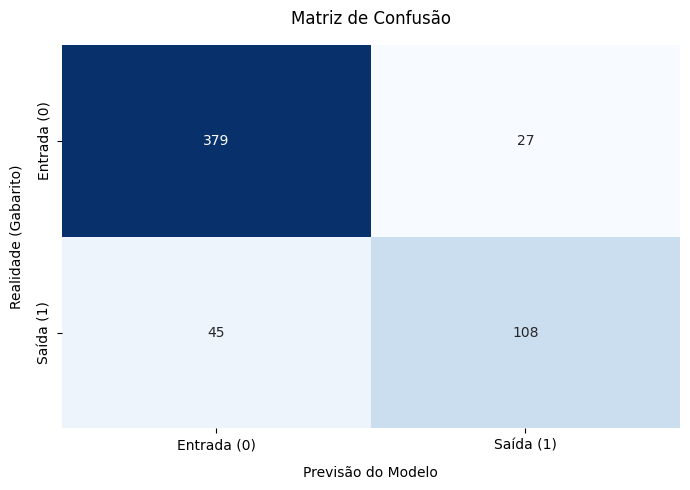

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("📥 Carregando o estado ótimo do modelo para geração de métricas...")
model_gunshot.load_state_dict(torch.load('melhor_modelo_tiros.pth'))
model_gunshot.eval()

y_true = []
y_pred = []
y_prob_both = []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model_gunshot(images)

        # Softmax extrai as probabilidades de ambas as classes
        probabilities = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_prob_both.extend(probabilities.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob_both = np.array(y_prob_both)

# One-Hot Encoding para permitir AUC multiclasse/simétrico (M, m, W)
y_true_onehot = np.eye(2)[y_true]

classes = ['Entrada (0)', 'Saída (1)']

# ==========================================
# EXTRAÇÃO DE VARIÁVEIS DA MATRIZ DE CONFUSÃO
# ==========================================
cm = confusion_matrix(y_true, y_pred)

# FP, FN, TP e TN extraídos conforme as fórmulas do artigo
FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

support_per_class = cm.sum(axis=1)

# ==========================================
# CÁLCULO DE MÉTRICAS (Fórmulas do Artigo)
# ==========================================
acc = accuracy_score(y_true, y_pred)

metrics = {}
averages = ['macro', 'micro', 'weighted']

# Precision, Recall, F1-Score e AUC usando Scikit-Learn (mesma matemática)
for avg in averages:
    metrics[f'Prec_{avg}'] = precision_score(y_true, y_pred, average=avg, zero_division=0)
    metrics[f'Rec_{avg}'] = recall_score(y_true, y_pred, average=avg, zero_division=0)
    metrics[f'F1_{avg}'] = f1_score(y_true, y_pred, average=avg, zero_division=0)
    metrics[f'AUC_{avg}'] = roc_auc_score(y_true_onehot, y_prob_both, average=avg)

# Especificidade: TN / (TN + FP)
specificity_per_class = TN / (TN + FP)

# Macro: Média aritmética pura das classes
metrics['Spec_macro'] = np.mean(specificity_per_class)

# Micro: Soma global de TN e FP
metrics['Spec_micro'] = TN.sum() / (TN.sum() + FP.sum())

# Weighted: Média ponderada pela quantidade de amostras de cada classe
metrics['Spec_weighted'] = np.average(specificity_per_class, weights=support_per_class)


# ==========================================
# GERAÇÃO DA TABELA DO ARTIGO (Console)
# ==========================================
print("\n" + "="*145)
print(" TABELA 5 - PERFORMANCE METRICS (FORMATO CIENTÍFICO)")
print("="*145)

# Cabeçalho Superior
header1 = f"{'Architecture':<14} {'Variant':<10} {'ACC':<7} "
header1 += f"{'Precision':<23} {'Recall':<23} {'F1-Score':<23} {'AUC':<23} {'Specificity':<23}"
print(header1)

# Cabeçalho Inferior (M = Macro, m = micro, W = Weighted)
header2 = f"{'':<33} "
for _ in range(5):
    header2 += f"{'M':<7} {'m':<7} {'W':<7}   "
print(header2)
print("-" * 145)

# Linha do Modelo
row = f"{'TransferKAN':<14} {'Gunshot':<10} {acc:<7.3f} "
row += f"{metrics['Prec_macro']:<7.3f} {metrics['Prec_micro']:<7.3f} {metrics['Prec_weighted']:<7.3f}   "
row += f"{metrics['Rec_macro']:<7.3f} {metrics['Rec_micro']:<7.3f} {metrics['Rec_weighted']:<7.3f}   "
row += f"{metrics['F1_macro']:<7.3f} {metrics['F1_micro']:<7.3f} {metrics['F1_weighted']:<7.3f}   "
row += f"{metrics['AUC_macro']:<7.3f} {metrics['AUC_micro']:<7.3f} {metrics['AUC_weighted']:<7.3f}   "
row += f"{metrics['Spec_macro']:<7.3f} {metrics['Spec_micro']:<7.3f} {metrics['Spec_weighted']:<7.3f}"
print(row)
print("="*145 + "\n")


# ==========================================
# PLOTAGEM DA MATRIZ E RELATÓRIO PADRÃO
# ==========================================
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, cbar=False)
plt.title('Matriz de Confusão', pad=15)
plt.xlabel('Previsão do Modelo', labelpad=10)
plt.ylabel('Realidade (Gabarito)', labelpad=10)
plt.tight_layout()
plt.show()